# COMP0005 - GROUP COURSEWORK
# Experimental Evaluation of Search Data Structures and Algorithms

The cell below defines **AbstractSearchInterface**, an interface to support basic insert/search operations; you will need to implement this three times, to realise your three search data structures of choice among: (1) *2-3 Tree*, (2) *AVL Tree*, (3) *LLRB BST*; (4) *B-Tree*; and (5) *Scapegoat Tree*. <br><br>**Do NOT modify the next cell** - use the dedicated cells further below for your implementation instead. <br>

In [184]:
# DO NOT MODIFY THIS CELL

from abc import ABC, abstractmethod  

class AbstractSearchInterface(ABC):
    '''
    Abstract class to support search/insert operations (plus underlying data structure)
    
    '''
        
    @abstractmethod
    def insertElement(self, element):     
        '''
        Insert an element in a search tree
            Parameters:
                    element: string to be inserted in the search tree (string)

            Returns:
                    "True" after successful insertion, "False" if element is already present (bool)
        '''
        
        pass 
    

    @abstractmethod
    def searchElement(self, element):
        '''
        Search for an element in a search tree
            Parameters:
                    element: string to be searched in the search tree (string)

            Returns:
                    "True" if element is found, "False" otherwise (bool)
        '''

        pass

Use the cell below to define any auxiliary data structure and python function you may need. Leave the implementation of the main API to the next code cells instead.

In [185]:
# ADD AUXILIARY DATA STRUCTURE DEFINITIONS AND HELPER CODE HERE

class TwoThreeNode:
    '''Node for a 2-3 tree, storing 1 or 2 values and up to 3 children.'''
    def __init__(self, vals, parent=None, children=None):
        self.vals = vals
        self.parent = parent
        self.children = children if children is not None else []

    def is_two_node(self):
        '''Returns True if this node has exactly one value (two children).'''
        return len(self.vals) == 1
    
    def is_leaf(self):
        '''Returns True if this node has no children.'''
        return len(self.children) == 0



class AVLNode:
    '''Node for an AVL tree, storing an element, left/right children, and height.'''
    def __init__(self, element, right = None, left = None):
        self.element = element
        self.right = right
        self.left = left
        self.height = 1
        
def AVLGetHeight(node):
    '''Returns height of node, or 0 if node is None.'''
    if node is None:
        return 0
    return node.height

def AVLGetBalance(node):
    '''Returns balance factor of node (right height minus left height).'''
    return AVLGetHeight(node.right) - AVLGetHeight(node.left)



class ScapegoatNode:
    '''Node for a Scapegoat tree, storing an element and left/right children.'''
    def __init__(self, element):
        self.element = element
        self.left = None
        self.right = None

Use the cell below to implement the requested API by means of **2-3 Tree** (if among your chosen data structure).

In [186]:
class TwoThreeTree(AbstractSearchInterface):
    '''2-3 tree implementation where each node holds 1-2 values and has 2-3 children.'''
    def __init__(self):
        super().__init__()
        self.root = None
        
    def insertElement(self, element):
        '''Inserts element into the 2-3 tree. Returns True if inserted, False if duplicate.'''
        # If tree is empty create a root
        if not self.root:
            self.root = TwoThreeNode([element])
            return True
        
        # Search for insertion spot
        node = self._findNode(element)
        if not node:
            return False

        #Insert in node
        if element > node.vals[-1]:
            node.vals.append(element)
        elif element < node.vals[0]:
            node.vals.insert(0, element)
        else:
            node.vals.insert(1, element)

        # Bubble up if more than 3 keys
        while node and len(node.vals) == 3:
            if not node.parent:
                self.root = TwoThreeNode([node.vals.pop(1)])
            elif node.vals[1] < node.parent.vals[0]:
                node.parent.vals.insert(0, node.vals.pop(1))
            elif node.vals[1] > node.parent.vals[-1]:
                node.parent.vals.append(node.vals.pop(1))
            else:
                node.parent.vals.insert(1, node.vals.pop(1))

            # Split the child nodes
            parent = node.parent if node.parent else self.root
            sub_children = [node.children[:2], node.children[2:]] if node.children else [[], []]
            children = [TwoThreeNode([node.vals[0]], parent=parent, children=sub_children[0]), 
                        TwoThreeNode([node.vals[1]], parent=parent, children=sub_children[1])]
            
            # Reconfigure parent/children relationships
            for i in range(2):
                for child in sub_children[i]:
                    child.parent = children[i]
            
            if parent is self.root and not parent.children:
                parent.children = children
            else:
                node_index = parent.children.index(node)
                parent.children = parent.children[:node_index] + children + parent.children[node_index + 1:]
    
            node = node.parent

        return True
    
    # _findNode returns None only when the element is already present.
    def searchElement(self, element):
        '''Searches for element in the 2-3 tree. Returns True if found, False otherwise.'''
        if not self.root: return False
        return self._findNode(element) == None
    
    # Returns the leaf where a new element should be inserted, or None if it already exists.
    def _findNode(self, element):    
        '''Returns the leaf node where element should be inserted, or None if already present.'''
        node = self.root
        while True:
            # Check if the element is in this node
            if element in node.vals:
                return None
            # Return insertion spot
            if node.is_leaf():
                return node   
            # 2-node: only 2 children, 1 key
            if node.is_two_node():
                if element > node.vals[0]:
                    node = node.children[1]
                else:
                    node = node.children[0]
            # 3-node: 3 children, 2 keys
            else:
                if element > node.vals[1]:
                    node = node.children[2]
                elif element < node.vals[0]:
                    node = node.children[0]
                else:
                    node = node.children[1]

Use the cell below to implement the requested API by means of **AVL Tree** (if among your chosen data structure).

In [187]:
class AVLTree(AbstractSearchInterface):
    '''Self-balancing binary search tree using AVL rotations to maintain O(log n) operations.'''
    def __init__(self):
        self.root = None

    def insertElement(self, element):
        '''Inserts element into AVL tree. Returns True if inserted, False if duplicate.'''
        self.root, inserted = self._insertElementHelper(self.root, element)
        return inserted

    def searchElement(self, element):
        '''Iteratively searches for element in AVL tree. Returns True if found, False otherwise.'''
        node = self.root
        while node is not None:
            if element > node.element:
                node = node.right
            elif element < node.element:
                node = node.left
            else:
                return True
        return False
    
    def _rotateLeft(self, node):
        '''Performs a left rotation on node to fix right-heavy imbalance. Returns new subtree root.'''
        newNode = node.right
        temp = newNode.left
        newNode.left = node
        node.right = temp
        node.height = 1 + max(AVLGetHeight(node.left), AVLGetHeight(node.right))
        newNode.height = 1 + max(AVLGetHeight(newNode.left), AVLGetHeight(newNode.right))
        return newNode
    
    def _rotateRight(self, node):
        '''Performs a right rotation on node to fix left-heavy imbalance. Returns new subtree root.'''
        newNode = node.left
        temp = newNode.right
        newNode.right = node
        node.left = temp
        node.height = 1 + max(AVLGetHeight(node.left), AVLGetHeight(node.right))
        newNode.height = 1 + max(AVLGetHeight(newNode.left), AVLGetHeight(newNode.right))
        return newNode

    def _insertElementHelper(self, node, element):
        '''Recursively inserts element into subtree at node, rebalancing on the way back up. Returns (node, inserted) tuple.'''
        if node is None:
            return AVLNode(element), True

        if element > node.element:
            node.right, inserted = self._insertElementHelper(node.right, element)
        elif element < node.element:
            node.left, inserted = self._insertElementHelper(node.left, element)
        else:
            return node, False  

        node.height = 1 + max(AVLGetHeight(node.left), AVLGetHeight(node.right))
        balance = AVLGetBalance(node)
        
        # RR
        if balance > 1 and AVLGetBalance(node.right) >= 0:
            node = self._rotateLeft(node)
        # LL
        elif balance < -1 and AVLGetBalance(node.left) <= 0:
            node = self._rotateRight(node)
        # RL
        elif balance > 1 and AVLGetBalance(node.right) < 0:
            node.right = self._rotateRight(node.right)
            node = self._rotateLeft(node)
        # LR
        elif balance < -1 and AVLGetBalance(node.left) > 0:
            node.left = self._rotateLeft(node.left)
            node = self._rotateRight(node)

        return node, inserted

Use the cell below to implement the requested API by means of **Scapegoat Tree** (if among your chosen data structure).

In [188]:
class ScapegoatTree(AbstractSearchInterface):
    '''Self-balancing BST that lazily rebuilds unbalanced subtrees using a scapegoat node.'''
    def __init__(self, alpha=2/3):
        self.root = None
        self.n = 0
        self.max_size = 0
        self.alpha = alpha
        
    def insertElement(self, element):
        '''Inserts element into scapegoat tree, rebuilding if depth exceeds allowed threshold. Returns True if inserted, False if duplicate.'''
        path = []
        parent = None
        node = self.root

        while node is not None:
            if element == node.element:
                return False
            path.append(node)
            parent = node
            if element < node.element:
                node = node.left
            else:
                node = node.right

        new_node = ScapegoatNode(element)

        if parent is None:
            self.root = new_node
        else:
            if element < parent.element:
                parent.left = new_node
            else:
                parent.right = new_node

        self.n += 1
        self.max_size = max(self.max_size, self.n)

        depth = len(path)
        allowed = self._log(self.n, 1 / self.alpha)
        if depth > allowed:
            self._find_and_rebuild(path)
        return True
    
    def searchElement(self, element):  
        '''Iteratively searches for element in scapegoat tree. Returns True if found, False otherwise.'''
        node = self.root
        while node is not None:
            if element == node.element:
                return True
            if element < node.element:
                node = node.left
            else:
                node = node.right
        return False

    # helper functions
    def _size(self, node):
        '''Recursively returns the number of nodes in subtree rooted at node.'''
        if node is None:
            return 0
        return 1 + self._size(node.left) + self._size(node.right)

    def _in_order_traversal(self, node, array):
        '''Appends elements of subtree rooted at node to array in sorted order.'''
        if node:
            self._in_order_traversal(node.left, array)
            array.append(node.element)
            self._in_order_traversal(node.right, array)   

    def _build_balanced(self, array, min, max):
        '''Recursively builds a balanced BST from a sorted array slice. Returns root of new subtree.'''
        if min > max:
            return None
        avg = (min + max) // 2
        node = ScapegoatNode(array[avg])
        node.left = self._build_balanced(array, min, avg - 1)
        node.right = self._build_balanced(array, avg + 1, max)
        return node
    
    def _log(self, n, base):
        '''Approximates log of n in given base without using the math library.'''
        result = 0
        while n >= base:
            n /= base
            result += 1
        return result
    
    def _find_and_rebuild(self, path):
        '''Finds the highest scapegoat node in path and rebuilds its subtree into a balanced tree.'''
        for i in range(len(path) - 1, -1, -1):
            scapegoat = path[i]
            left_size = self._size(scapegoat.left)
            right_size = self._size(scapegoat.right)
            total = left_size + right_size + 1

            if max(left_size, right_size) > self.alpha * total:
                parent = path[i - 1] if i > 0 else None

                nodes = []
                self._in_order_traversal(scapegoat, nodes)
                new_subtree = self._build_balanced(nodes, 0, len(nodes) - 1)

                if parent is None:
                    self.root = new_subtree
                else:
                    if parent.left == scapegoat:
                        parent.left = new_subtree
                    else:
                        parent.right = new_subtree

                return

Use the cell below to implement the **synthetic data generator** needed by your experimental framework (be mindful of code readability and reusability).

In [189]:
import string
import random

class TestDataGenerator():
    '''
    A class to generate synthetic string datasets for insertion and search experiments.

    Attributes
    ----------
    seed : int
        Random seed for reproducibility.

    Methods
    -------
    generate_random_strings(count, min_length, max_length)
        Generate random strings of varying length.

    generate_sorted_strings(count)
        Generate strings and return them in sorted (alphabetical) order.

    generate_nearly_sorted_strings(count, swap_fraction)
        Generate mostly sorted strings with a fraction of elements randomly swapped.

    generate_strings_with_duplicates(count, duplicate_fraction)
        Generate a dataset containing repeated strings.

    generate_search_hits(inserted_strings, count)
        Generate search queries guaranteed to exist in the dataset.

    generate_search_misses(inserted_strings, count, length)
        Generate search queries guaranteed not to exist in the dataset.
    '''
    
    def __init__(self, seed=27):
        random.seed(seed)

    # Notes:
    # - Reproducibility depends on the order in which generator methods are called,
    #   because they all share Python's global random state.
    # - Short string lengths combined with very large counts may naturally produce duplicates.
    # Insertion dataset generators
    # Random order
    def generate_random_strings(self, count, min_length=4, max_length=16):
        strings = []
        for i in range(count):
            l = random.randint(min_length, max_length)
            s = ''.join(random.choices(string.ascii_lowercase, k=l))
            strings.append(s)
        return strings
    
    # Sorted (alphabetical) order
    def generate_sorted_strings(self, count):
        strings = self.generate_random_strings(count)
        strings.sort()
        return strings
    
    # Nearly sorted (mostly sorted with random swaps)
    def generate_nearly_sorted_strings(self, count, swap_fraction=0.2):
        strings = self.generate_sorted_strings(count)
        num_swaps = int(count * swap_fraction)
        for i in range(num_swaps):
            idx1 = random.randint(0, count - 1)
            idx2 = random.randint(0, count - 1)
            strings[idx1], strings[idx2] = strings[idx2], strings[idx1]
        return strings
    
    # Strings with duplicates
    def generate_strings_with_duplicates(self, count, duplicate_fraction=0.4):
        unique_count = int(count * (1 - duplicate_fraction))
        unique_strings = self.generate_random_strings(unique_count)
        duplicates = random.choices(unique_strings, k=count - unique_count)
        result = unique_strings + duplicates
        random.shuffle(result)
        return result
    
    # Search dataset generators
    # Search targets that should be found
    def generate_search_hits(self, inserted_strings, count):
        return random.choices(inserted_strings, k=count)
    
    # Search targets that should not be found
    def generate_search_misses(self, inserted_strings, count, length=8):
        inserted_set = set(inserted_strings)
        misses = []
        while len(misses) < count:
            s = ''.join(random.choices(string.ascii_lowercase, k=length))
            if s not in inserted_set:
                misses.append(s)
        return misses

Use the cell below to implement the requested **experimental framework** (be mindful of code readability and reusability).

In [190]:
import timeit
import matplotlib.pyplot as plt

class ExperimentalFramework():
    '''
    A class to represent an experimental framework.

    Attributes
    ----------
    data_generator : TestDataGenerator
        Generator used to create synthetic datasets for experiments.
    sizes : list[int]
        Different dataset sizes used in the experiments.
    repeats : int
        Number of repeated runs used to average timings.

    Methods
    -------
    _average_time(build_and_run)
        Repeats an experiment several times and returns the average timing.

    time_insert(tree_class, data_generator_method)
        Times insertion for a specific tree class using a specific input-data generator.

    time_search(tree_class, data_generator_method)
        Builds a fresh tree from random strings for each size, then times searches
        using a specific search-target generator.

    plot_comparison(results, title)
        Plots timing results for all three tree implementations on one graph.
    '''
    
    def __init__(self, repeats=5):
        self.data_generator = TestDataGenerator()
        self.sizes = [100, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]
        self.repeats = repeats

    def _average_time(self, build_and_run):
        '''Returns mean time over repeated runs.'''
        times = [build_and_run() for _ in range(self.repeats)]
        return sum(times) / len(times)

    def time_insert(self, tree_class, data_generator_method):
        times = []
        for size in self.sizes:
            def build_and_run():
                '''Builds a fresh tree with generated data and returns insertion timing.'''
                data = data_generator_method(count=size)
                tree = tree_class()

                def run():
                    for e in data:
                        tree.insertElement(e)

                return timeit.timeit(run, number=1)

            times.append(self._average_time(build_and_run))
        return times
    
    def time_search(self, tree_class, search_method):
        times = []
        for size in self.sizes:
            def build_and_run():
                '''Builds a fresh tree with generated data and returns search timing.'''
                strings = self.data_generator.generate_random_strings(count=size)
                tree = tree_class()

                inserted_strings = []
                for s in strings:
                    if tree.insertElement(s):
                        inserted_strings.append(s)
                strings_to_search = search_method(count=size, inserted_strings=inserted_strings)
                def run():
                    for e in strings_to_search:
                        tree.searchElement(e)
                return timeit.timeit(run, number=1)
            times.append(self._average_time(build_and_run))
        return times

    
    def plot_comparison(self, results, title):
        plt.figure(figsize=(12, 5))
        for tree_name, times in results.items():
            plt.plot(self.sizes, times, marker='o', label=tree_name)

        plt.xscale("log")
        plt.xticks(self.sizes, [str(size) for size in self.sizes])
        plt.xlabel("Dataset size (logged)")
        plt.ylabel("Time (seconds)")
        plt.title(title)
        plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
        plt.legend()
        plt.tight_layout()
        plt.show()

Use the cell below to illustrate the python code you used to **fully evaluate** your three chosen search data structures and algortihms. The code below should illustrate, for example, how you made used of the **TestDataGenerator** class to generate test data of various size and properties; how you instatiated the **ExperimentalFramework** class to  evaluate each data structure using such data, collect information about their execution time, plot results, etc. Any results you illustrate in the companion PDF report should have been generated using the code below.


--- 2-3 Tree ---
1. Empty tree search: PASSED
2. Single element insert/search: PASSED
3. Duplicate insertion: PASSED
4. Multiple elements: PASSED
5. Sorted input: PASSED
6. Reverse sorted input: PASSED
7. Stress test (10,000 elements): PASSED
8. Duplicate-heavy dataset: PASSED

--- AVL Tree ---
1. Empty tree search: PASSED
2. Single element insert/search: PASSED
3. Duplicate insertion: PASSED
4. Multiple elements: PASSED
5. Sorted input: PASSED
6. Reverse sorted input: PASSED
7. Stress test (10,000 elements): PASSED
8. Duplicate-heavy dataset: PASSED

--- Scapegoat ---
1. Empty tree search: PASSED
2. Single element insert/search: PASSED
3. Duplicate insertion: PASSED
4. Multiple elements: PASSED
5. Sorted input: PASSED
6. Reverse sorted input: PASSED
7. Stress test (10,000 elements): PASSED
8. Duplicate-heavy dataset: PASSED

All tests passed.


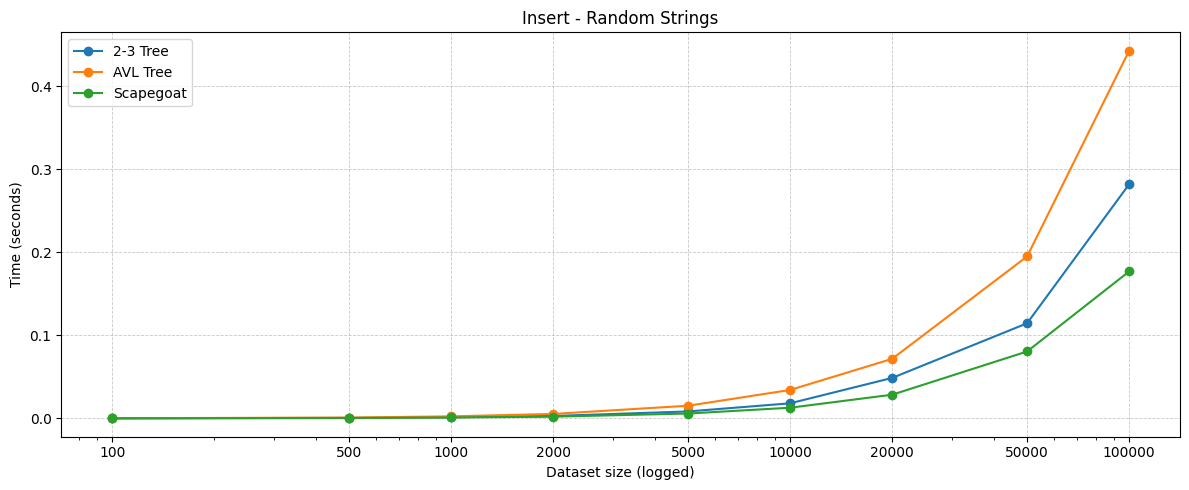

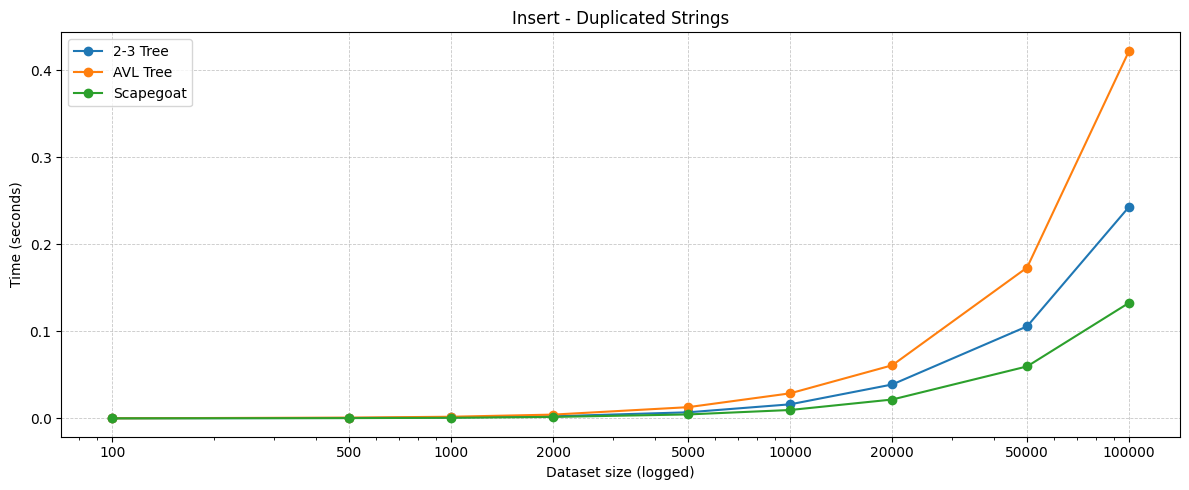

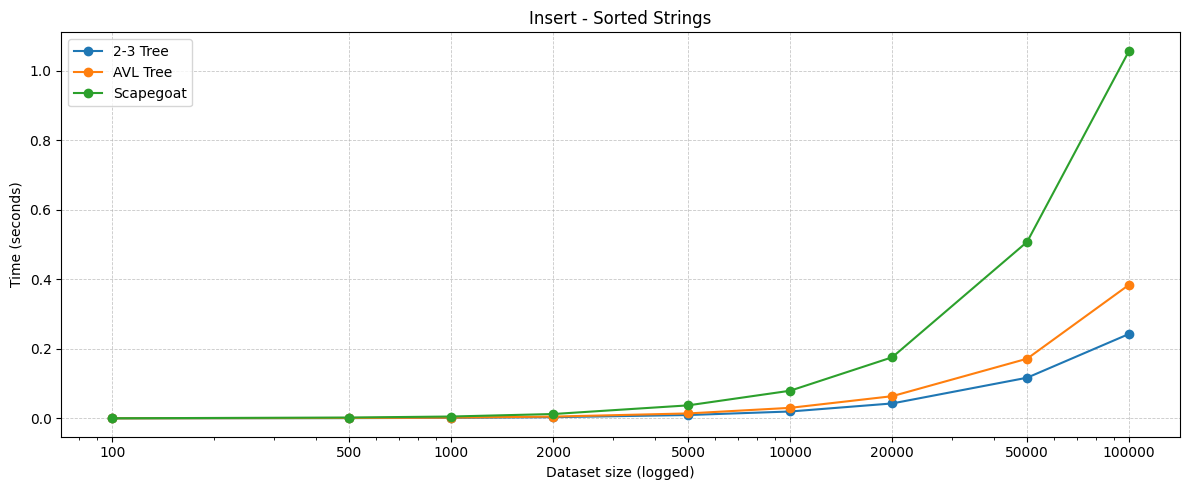

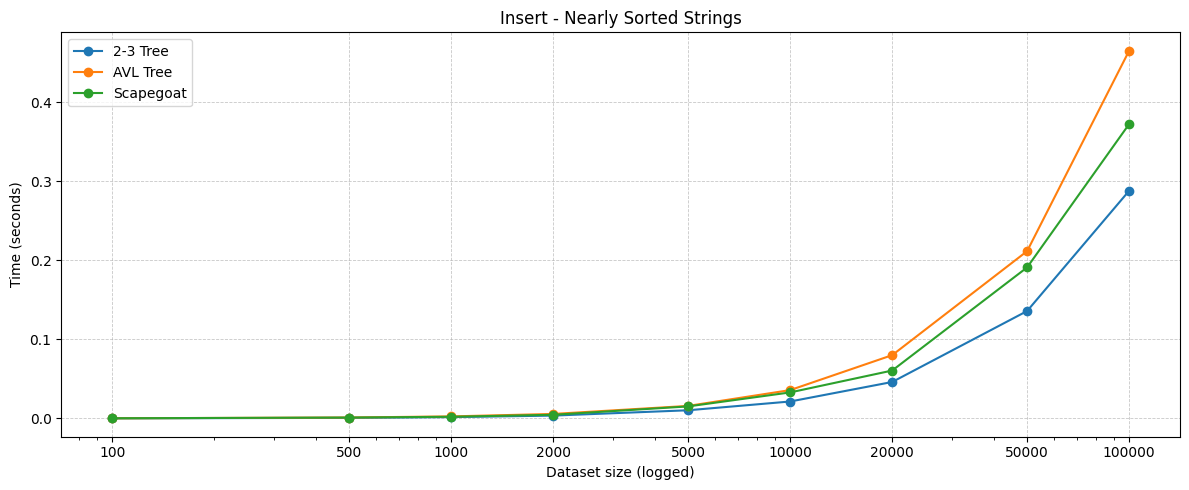

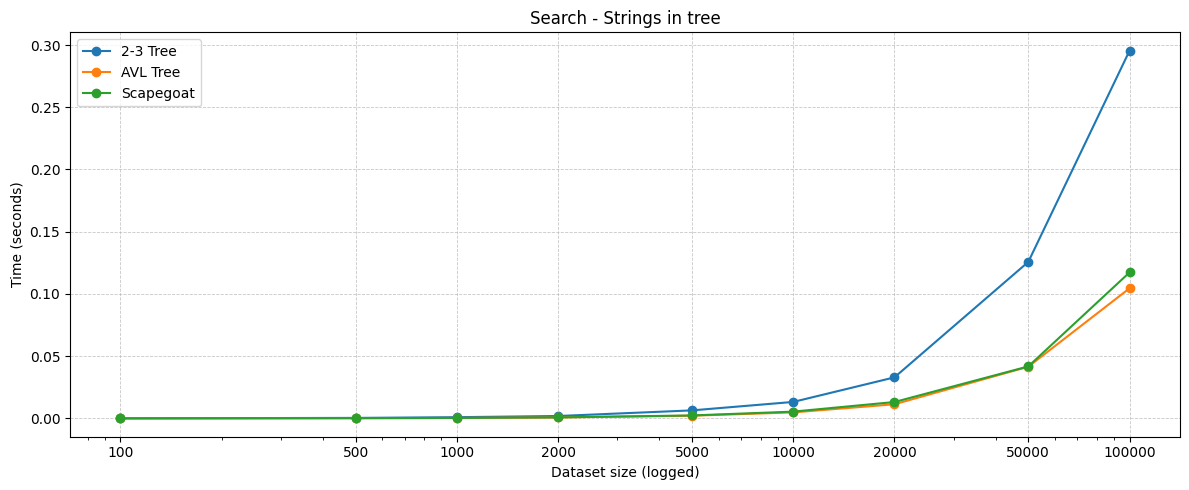

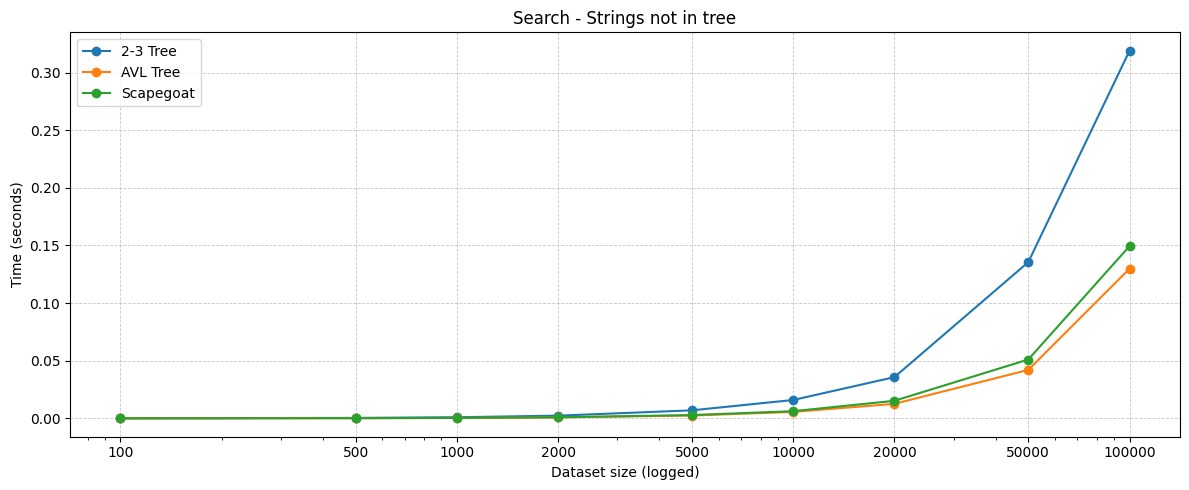

In [191]:
# ADD YOUR TEST CODE HERE 


# CORRECTNESS AND EDGE  CASE TESTING


def run_tests():
    trees = {"2-3 Tree": TwoThreeTree, "AVL Tree": AVLTree, "Scapegoat": ScapegoatTree}
    gen = TestDataGenerator()

    for name, TreeClass in trees.items():
        print(f"\n--- {name} ---")

        # 1. Empty tree search
        tree = TreeClass()
        assert tree.searchElement("a") == False
        print("1. Empty tree search: PASSED")

        # 2. Single element insert and search
        tree = TreeClass()
        assert tree.insertElement("hello") == True
        assert tree.searchElement("hello") == True
        assert tree.searchElement("world") == False
        print("2. Single element insert/search: PASSED")

        # 3. Duplicate insertion
        tree = TreeClass()
        assert tree.insertElement("hello") == True
        assert tree.insertElement("hello") == False
        print("3. Duplicate insertion: PASSED")

        # 4. Multiple elements
        tree = TreeClass()
        for w in ["b", "a", "c", "d", "e"]:
            tree.insertElement(w)
        assert all(tree.searchElement(w) for w in ["b", "a", "c", "d", "e"])
        assert tree.searchElement("g") == False
        print("4. Multiple elements: PASSED")

        # 5. Sorted input (worst case for unbalanced trees)
        tree = TreeClass()
        sorted_words = sorted(["m", "n", "o", "p", "q", "r", "s", "t", "u", "v"])
        for w in sorted_words:
            tree.insertElement(w)
        assert all(tree.searchElement(w) for w in sorted_words)
        print("5. Sorted input: PASSED")

        # 6. Reverse sorted input
        tree = TreeClass()
        for w in reversed(sorted_words):
            tree.insertElement(w)
        assert all(tree.searchElement(w) for w in sorted_words)
        print("6. Reverse sorted input: PASSED")

        # 7. Stress test - 10000 random strings
        tree = TreeClass()
        inserted = [s for s in gen.generate_random_strings(10000) if tree.insertElement(s)]
        assert all(tree.searchElement(s) for s in inserted)
        assert tree.searchElement("thisshouldnotexist12345") == False
        print("7. Stress test (10,000 elements): PASSED")

        # 8. Duplicate-heavy dataset
        tree = TreeClass()
        inserted = [s for s in gen.generate_strings_with_duplicates(1000) if tree.insertElement(s)]
        assert all(tree.searchElement(s) for s in inserted)
        print("8. Duplicate-heavy dataset: PASSED")

run_tests()
print("\nAll tests passed.")

framework = ExperimentalFramework(repeats=3)

# Tuples of (generator method, graph title) for testing and plotting
insert_data_generation = [(framework.data_generator.generate_random_strings, "Insert - Random Strings"),
                          (framework.data_generator.generate_strings_with_duplicates, "Insert - Duplicated Strings"),
                          (framework.data_generator.generate_sorted_strings, "Insert - Sorted Strings"),
                          (framework.data_generator.generate_nearly_sorted_strings, "Insert - Nearly Sorted Strings")]

for method in insert_data_generation:
    results = {
        "2-3 Tree": framework.time_insert(TwoThreeTree, method[0]),
        "AVL Tree": framework.time_insert(AVLTree, method[0]),
        "Scapegoat": framework.time_insert(ScapegoatTree, method[0]),
    }
    framework.plot_comparison(results, method[1])

# Tuples of (generator method, graph title) for testing and plotting
search_data_generation = [(framework.data_generator.generate_search_hits, "Search - Strings in tree"),
                          (framework.data_generator.generate_search_misses, "Search - Strings not in tree")]

for method in search_data_generation:
    results = {
        "2-3 Tree": framework.time_search(TwoThreeTree, method[0]),
        "AVL Tree": framework.time_search(AVLTree, method[0]),
        "Scapegoat": framework.time_search(ScapegoatTree, method[0]),
    }
    framework.plot_comparison(results, method[1])